# 测试image caption

## 1. CNN + LSTM方式

我们将图像生成标题的推理部分代码放在这个单独的文件中，用于体会深度学习模型 训练-推理 分离的机制下，需要“分享”的代码量。如果开发者不希望透露更多的训练模型的细节，可以通过只分发推理代码+模型文件的方式，以保护自己产品的技术细节。

In [1]:
import os
import pickle
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

In [2]:
import torch
import torchvision
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from torch.nn.utils.rnn import pack_padded_sequence

在测试代码中，我们需要三个主要文件：训练好的模型权重××.ckpt、测试图像xxx.jpeg以及字典文件vocabxxx.pkl。所需部分代码，如模型的定义、字典数据结构的定义，则必须与训练时一致（实际项目中往往存储在dataset.py、model.py、utile.py等三个文件中）

In [ ]:
## 1

In [3]:
class Vocabulary(object):
    """Simple vocabulary wrapper."""
    def __init__(self):
        self.word2idx = {}
        self.idx2word = {}
        self.idx = 0

    def add_word(self, word):
        if not word in self.word2idx:
            self.word2idx[word] = self.idx
            self.idx2word[self.idx] = word
            self.idx += 1

    def __call__(self, word):
        if not word in self.word2idx:
            return self.word2idx['<unk>']
        return self.word2idx[word]

    def __len__(self):
        return len(self.word2idx)

In [4]:
with open('vocab_coco.pkl', 'rb') as f:
        vocab = pickle.load(f)

In [ ]:
## 2

In [5]:
class EncoderCNN(nn.Module):
    def __init__(self, embed_size):
        super(EncoderCNN, self).__init__()
        resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)  # originally is resnet152 here, and pretrained=True is deprecated already
        modules = list(resnet.children())[:-1]      # delete the last fc layer.
        self.resnet = nn.Sequential(*modules)
        self.linear = nn.Linear(resnet.fc.in_features, embed_size)
        self.bn = nn.BatchNorm1d(embed_size, momentum=0.01)
        
    def forward(self, images):
        with torch.no_grad():
            features = self.resnet(images)
        features = features.reshape(features.size(0), -1)
        features = self.bn(self.linear(features))
        return features

In [6]:
class DecoderRNN(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size, num_layers, max_seq_length=20):
        super(DecoderRNN, self).__init__()
        self.embed = nn.Embedding(vocab_size, embed_size)
        self.lstm = nn.LSTM(embed_size, hidden_size, num_layers, batch_first=True)
        self.linear = nn.Linear(hidden_size, vocab_size)
        self.max_seg_length = max_seq_length
        
    def forward(self, features, captions, lengths):
        embeddings = self.embed(captions)
        embeddings = torch.cat((features.unsqueeze(1), embeddings), 1)
        packed = pack_padded_sequence(embeddings, lengths, batch_first=True) 
        hiddens, _ = self.lstm(packed)
        outputs = self.linear(hiddens[0])
        return outputs
    
    def sample(self, features, states=None):
        sampled_ids = []
        inputs = features.unsqueeze(1)
        for i in range(self.max_seg_length):
            hiddens, states = self.lstm(inputs, states)          # hiddens: (batch_size, 1, hidden_size)
            outputs = self.linear(hiddens.squeeze(1))            # outputs:  (batch_size, vocab_size)
            _, predicted = outputs.max(1)                        # predicted: (batch_size)
            sampled_ids.append(predicted)
            inputs = self.embed(predicted)                       # inputs: (batch_size, embed_size)
            inputs = inputs.unsqueeze(1)                         # inputs: (batch_size, 1, embed_size)
        sampled_ids = torch.stack(sampled_ids, 1)                # sampled_ids: (batch_size, max_seq_length)
        return sampled_ids

In [7]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

In [8]:
# models
embed_size = 256
hidden_size = 512
num_layers = 1
encoder = EncoderCNN(embed_size).to(device)
decoder = DecoderRNN(embed_size, hidden_size, len(vocab), num_layers).to(device)

In [9]:
# Load the trained model parameters
model_index = 30
model_path = 'checkpoints/caption'

<All keys matched successfully>

In [21]:
encoder.load_state_dict(torch.load(os.path.join(model_path, 'encoder-{}-{}.ckpt'.format(model_index, 4600))))
encoder.eval()

EncoderCNN(
  (resnet): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
          (0): Conv2d(64

In [22]:
decoder.load_state_dict(torch.load(os.path.join(model_path, 'decoder-{}-{}.ckpt'.format(model_index, 4600))))
decoder.eval()

DecoderRNN(
  (embed): Embedding(11544, 256)
  (lstm): LSTM(256, 512, batch_first=True)
  (linear): Linear(in_features=512, out_features=11544, bias=True)
)

In [ ]:
## 3

In [11]:
img = Image.open('./imgs/example.jpeg').convert('RGB')

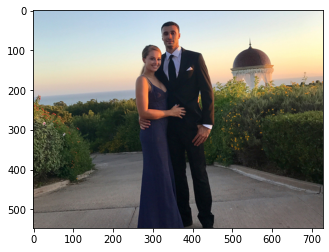

In [12]:
plt.imshow(np.asarray(img))

In [13]:
img = img.resize([224,224], Image.ANTIALIAS)  # Image.LANCZOS

In [14]:
transform = transforms.Compose([
        transforms.ToTensor(), 
        transforms.Normalize((0.485, 0.456, 0.406), 
                             (0.229, 0.224, 0.225))])

In [15]:
img = transform(img).unsqueeze(0)

In [16]:
img_tensor = img.to(device)

In [20]:
img.shape

torch.Size([1, 3, 224, 224])

In [23]:
feature = encoder(img_tensor)    # 一般来说，先调用encoder.eval(), 以防止推理时只有1个样本而造成batch normalization操作报错

In [24]:
sampled_ids = decoder.sample(feature)

In [25]:
sampled_ids = sampled_ids[0].cpu().numpy() 
print(sampled_ids)

[   1    4  115   41    4 1413   17 1027  335   41   11  126    4  431
   13    2    2    2    2    2]


In [26]:
# Convert word_ids to words
sampled_caption = []
for word_id in sampled_ids:
    word = vocab.idx2word[word_id]
    sampled_caption.append(word)
    if word == '<end>':
        break
sentence = ' '.join(sampled_caption)
print (sentence)

<start> a man in a suit and tie standing in front of a building . <end>


## 2. Transformer 方式

Transformer网络写起来比CNN要复杂一些，但做Image Captioning任务来说，基于Transformer的模型表现得更好一些。

请感兴趣的读者继续补全